In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Task 1: Tải và xử lý tài liệu

In [2]:
import os

def load_conllu(file_path):
    sentences = []
    current_sentence = []

    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()

                if line.startswith('#'):
                    continue

                if not line:
                    if current_sentence:
                        sentences.append(current_sentence)
                        current_sentence = []
                    continue

                fields = line.split('\t')
                if len(fields) < 4:
                    continue

                if '-' in fields[0] or '.' in fields[0]:
                    continue

                word = fields[1]
                upos = fields[3]

                current_sentence.append((word, upos))
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return []

    if current_sentence:
        sentences.append(current_sentence)

    return sentences

base_dir = os.path.join('data', 'UD_English-EWT')
train_path = os.path.join(base_dir, 'en_ewt-ud-train.conllu')
dev_path = os.path.join(base_dir, 'en_ewt-ud-dev.conllu')
test_path = os.path.join(base_dir, 'en_ewt-ud-test.conllu')

train_sentences = load_conllu(train_path)
dev_sentences = load_conllu(dev_path)
test_sentences = load_conllu(test_path)

print(f"Number of training sentences: {len(train_sentences)}")
print(f"Number of dev sentences: {len(dev_sentences)}")
print(f"Number of test sentences: {len(test_sentences)}")
if train_sentences:
    print('\nExample sentence (first 5 tokens):')
    print(train_sentences[0][:5])

Number of training sentences: 12544
Number of dev sentences: 2001
Number of test sentences: 2077

Example sentence (first 5 tokens):
[('Al', 'PROPN'), ('-', 'PUNCT'), ('Zaman', 'PROPN'), (':', 'PUNCT'), ('American', 'ADJ')]


In [ ]:
from collections import Counter

def build_vocab(sentences, min_freq=2):
    """
    Xây dựng từ điển từ danh sách các câu.

    Args:
        sentences: List[List[Tuple[str, str]]] - Danh sách các câu
        min_freq: int - Tần suất tối thiểu để từ được đưa vào từ điển

    Returns:
        word_to_ix: Dict[str, int] - Từ điển từ -> index
        tag_to_ix: Dict[str, int] - Từ điển tag -> index
    """
    # Count word and tag frequencies
    word_counter = Counter()
    tag_counter = Counter()

    for sentence in sentences:
        for word, tag in sentence:
            word_counter[word] += 1
            tag_counter[tag] += 1

    # Build word vocabulary with special tokens
    word_to_ix = {'<PAD>': 0, '<UNK>': 1}
    for word, count in word_counter.items():
        if count >= min_freq:
            word_to_ix[word] = len(word_to_ix)

    # Build tag vocabulary with PAD token
    tag_to_ix = {'<PAD>': 0}
    for tag in tag_counter.keys():
        tag_to_ix[tag] = len(tag_to_ix)

    return word_to_ix, tag_to_ix

# Build vocabularies from training data
word_to_ix, tag_to_ix = build_vocab(train_sentences, min_freq=2)

# Create reverse mapping for tags
ix_to_tag = {v: k for k, v in tag_to_ix.items()}

print(f"Vocabulary size (words): {len(word_to_ix)}")
print(f"Vocabulary size (tags): {len(tag_to_ix)}")
print(f"\nTag vocabulary: {list(tag_to_ix.keys())}")
print(f"\nFirst 20 words in vocabulary: {list(word_to_ix.keys())[:20]}")

# Task 2: Tạo Dataset và Dataloader

In [3]:
from collections import Counter

def build_vocab(sentences, min_freq=2):
    word_counter = Counter()
    tag_counter = Counter()

    for sentence in sentences:
        for word, tag in sentence:
            word_counter[word] += 1
            tag_counter[tag] += 1

    tag_to_ix = {'<PAD>': 0}
    for tag in tag_counter.keys():
        tag_to_ix[tag] = len(tag_to_ix)

    word_to_ix = {'<PAD>': 0, '<UNK>': 1}
    for word, count in word_counter.items():
        if count >= min_freq:
            word_to_ix[word] = len(word_to_ix)

    return word_to_ix, tag_to_ix

word_to_ix, tag_to_ix = build_vocab(train_sentences, min_freq=2)

ix_to_tag = {v: k for k, v in tag_to_ix.items()}

print(f"Vocabulary size: {len(word_to_ix)}")
print(f"Vocabulary size: {len(tag_to_ix)}")
print(f"Tag vocabulary: {list(tag_to_ix.keys())}")
print(f"First 20 words in vocabulary: {list(word_to_ix.keys())[:20]}")

Vocabulary size: 9875
Vocabulary size: 18
Tag vocabulary: ['<PAD>', 'PROPN', 'PUNCT', 'ADJ', 'NOUN', 'VERB', 'DET', 'ADP', 'AUX', 'PRON', 'PART', 'SCONJ', 'NUM', 'ADV', 'CCONJ', 'X', 'INTJ', 'SYM']
First 20 words in vocabulary: ['<PAD>', '<UNK>', 'Al', '-', 'Zaman', ':', 'American', 'forces', 'killed', 'Shaikh', 'al', ',', 'the', 'preacher', 'at', 'mosque', 'in', 'town', 'of', 'Qaim']


In [4]:
class POSDataset(Dataset):
    def __init__(self, sentences, word_to_ix, tag_to_ix, lowercase=False):
        self.word_to_ix = word_to_ix
        self.tag_to_ix = tag_to_ix
        self.lowercase = lowercase

        # Indices cho OOV words / unknown tag
        self.unk_idx = word_to_ix.get('<UNK>', 1)
        self.pad_tag_idx = tag_to_ix.get('<PAD>', 0)
        self.unk_tag_idx = tag_to_ix.get('<UNK>', self.pad_tag_idx)

        # Pre-convert all sentences to tensors of indices (speeds up __getitem__)
        self.data = []
        for sentence in sentences:
            word_indices = []
            tag_indices = []
            for word, tag in sentence:
                w = word.lower() if self.lowercase and isinstance(word, str) else word
                word_idx = self.word_to_ix.get(w, self.unk_idx)
                tag_idx = self.tag_to_ix.get(tag, self.unk_tag_idx)
                word_indices.append(word_idx)
                tag_indices.append(tag_idx)

            # convert to long tensors
            if len(word_indices) == 0:
                # guard: empty sentence -> return a single PAD token
                self.data.append((torch.LongTensor([self.unk_idx]), torch.LongTensor([self.pad_tag_idx])))
            else:
                self.data.append((torch.LongTensor(word_indices), torch.LongTensor(tag_indices)))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

    def __repr__(self):
        return f"POSDataset(size={len(self)}, lowercase={self.lowercase})"

In [5]:
def collate_fn(batch):
    if len(batch) == 0:
        return torch.LongTensor([]), torch.LongTensor([]), torch.LongTensor([])

    sentences, tags = zip(*batch)
    sentences = [s if isinstance(s, torch.Tensor) else torch.LongTensor(s) for s in sentences]
    tags = [t if isinstance(t, torch.Tensor) else torch.LongTensor(t) for t in tags]
    sentences = [s.long() for s in sentences]
    tags = [t.long() for t in tags]

    lengths = torch.LongTensor([int(s.size(0)) for s in sentences])

    padded_sentences = pad_sequence(sentences, batch_first=True, padding_value=0)
    padded_tags = pad_sequence(tags, batch_first=True, padding_value=0)

    return padded_sentences, padded_tags, lengths

train_dataset = POSDataset(train_sentences, word_to_ix, tag_to_ix)
dev_dataset = POSDataset(dev_sentences, word_to_ix, tag_to_ix)
test_dataset = POSDataset(test_sentences, word_to_ix, tag_to_ix)

BATCH_SIZE = 32
NUM_WORKERS = 2
PIN_MEMORY = True if device.type == 'cuda' else False

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

dev_loader = DataLoader(
    dev_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print(f"Number of batches in train_loader: {len(train_loader)}")
print(f"Number of batches in dev_loader: {len(dev_loader)}")
print(f"Number of batches in test_loader: {len(test_loader)}")

# Test batch (keeps existing API)
batch_sentences, batch_tags, batch_lengths = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"Sentences: {batch_sentences.shape}")
print(f"Tags: {batch_tags.shape}")
print(f"Lengths: {batch_lengths.shape}")
print(f"\nLengths: {batch_lengths}")

Number of batches in train_loader: 392
Number of batches in dev_loader: 63
Number of batches in test_loader: 65

Batch shapes:
Sentences: torch.Size([32, 57])
Tags: torch.Size([32, 57])
Lengths: torch.Size([32])

Lengths: tensor([ 1,  2,  8, 29, 26, 26,  4,  8,  9, 11, 22, 25,  8, 11, 26, 32, 14,  7,
         2, 34, 19, 17,  8, 14,  9, 23, 24, 11, 57, 17, 12, 32])


# Task 3: Xây dựng model RNN

In [11]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class SimpleRNNForTokenClassification(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, tagset_size,
                 num_layers=1, bidirectional=False, dropout=0.0, rnn_type='RNN'):
        super(SimpleRNNForTokenClassification, self).__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        rnn_cls = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}.get(rnn_type, nn.RNN)

        self.rnn = rnn_cls(
            embedding_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_dim * self.num_directions, tagset_size)

    def forward(self, sentences, lengths=None):
        embeds = self.embedding(sentences)

        if lengths is not None:
            packed = pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)
            packed_out, _ = self.rnn(packed)
            rnn_out, _ = pad_packed_sequence(packed_out, batch_first=True, padding_value=0.0)
        else:
            rnn_out, _ = self.rnn(embeds)

        tag_scores = self.fc(rnn_out)
        return tag_scores

In [12]:
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
NUM_LAYERS = 1

model = SimpleRNNForTokenClassification(
    vocab_size=len(word_to_ix),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    tagset_size=len(tag_to_ix),
    num_layers=NUM_LAYERS
).to(device)

print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

SimpleRNNForTokenClassification(
  (embedding): Embedding(9875, 128, padding_idx=0)
  (rnn): RNN(128, 256, batch_first=True)
  (fc): Linear(in_features=256, out_features=18, bias=True)
)
Total parameters: 1367442
Trainable parameters: 1367442


# Task 4: Huấn luyện model

In [13]:
criterion = nn.CrossEntropyLoss(ignore_index=0)

# Optimizer
LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [14]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0

    for sentences, tags, lengths in tqdm(dataloader, desc="Training"):
        sentences = sentences.to(device)
        tags = tags.to(device)

        optimizer.zero_grad()

        tag_scores = model(sentences)  # [batch_size, seq_len, tagset_size]

        tag_scores = tag_scores.view(-1, tag_scores.shape[-1])
        tags = tags.view(-1)

        loss = criterion(tag_scores, tags)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    return avg_loss

# Task 5: Đánh giá model

In [15]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for sentences, tags, lengths in tqdm(dataloader, desc="Evaluating"):
            lengths = lengths.cpu().long()

            sentences = sentences.to(device)
            tags = tags.to(device)

            try:
                tag_scores = model(sentences, lengths)
            except TypeError:
                tag_scores = model(sentences)

            tag_scores_flat = tag_scores.view(-1, tag_scores.shape[-1])
            tags_flat = tags.view(-1)
            loss = criterion(tag_scores_flat, tags_flat)
            total_loss += loss.item()

            predictions = torch.argmax(tag_scores, dim=-1)  # [batch_size, seq_len]

            mask = (tags != 0)
            correct += ((predictions == tags) & mask).sum().item()
            total += mask.sum().item()

    avg_loss = total_loss / len(dataloader) if len(dataloader) > 0 else 0.0
    accuracy = correct / total if total > 0 else 0.0

    return avg_loss, accuracy

In [16]:
NUM_EPOCHS = 10

train_losses = []
val_losses = []
val_accuracies = []
best_val_acc = 0
best_model = None

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)

    val_loss, val_acc = evaluate(model, dev_loader, criterion, device)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"\nTrain Loss: {train_loss:.3f}")
    print(f"Dev Loss: {val_loss:.3f}")
    print(f"Dev Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model.state_dict().copy()
        print(f"Found best model\t\tAccuracy: {best_val_acc:.3f}")

print("Training completed!")
print(f"Best Dev Accuracy: {best_val_acc:.3f} ({best_val_acc*100:.2f}%)")

Starting training...

Epoch [1/10]


Evaluating: 100%|██████████| 63/63 [00:00<00:00, 111.57it/s]



Train Loss: 0.969
Dev Loss: 0.677
Dev Accuracy: 0.7818 (78.18%)
Found best model		Accuracy: 0.782
Epoch [2/10]


Evaluating: 100%|██████████| 63/63 [00:00<00:00, 209.47it/s]



Train Loss: 0.551
Dev Loss: 0.521
Dev Accuracy: 0.8313 (83.13%)
Found best model		Accuracy: 0.831
Epoch [3/10]


...


Train Loss: 0.155
Dev Loss: 0.388
Dev Accuracy: 0.8810 (88.10%)
Found best model		Accuracy: 0.881
Epoch [9/10]


Evaluating: 100%|██████████| 63/63 [00:00<00:00, 211.49it/s]



Train Loss: 0.133
Dev Loss: 0.401
Dev Accuracy: 0.8804 (88.04%)
Epoch [10/10]


Evaluating: 100%|██████████| 63/63 [00:00<00:00, 140.53it/s]


Train Loss: 0.114
Dev Loss: 0.417
Dev Accuracy: 0.8760 (87.60%)
Training completed!
Best Dev Accuracy: 0.881 (88.10%)


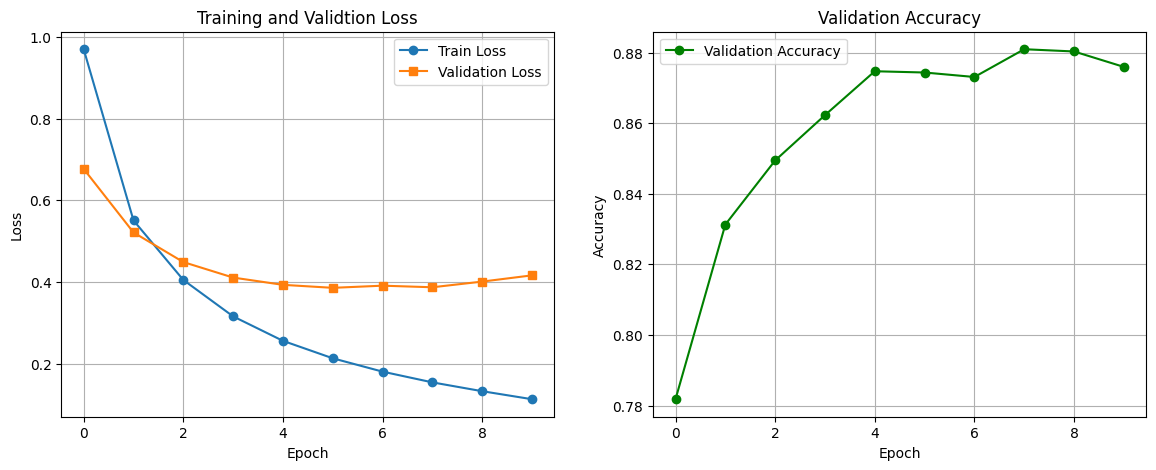

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Train Loss', marker='o')
axes[0].plot(val_losses, label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validtion Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(val_accuracies, label='Validation Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.show()

In [18]:
if best_model is not None:
    model.load_state_dict(best_model)
    print("Loaded best model")

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print("Result on test data")
print(f"Loss: {test_loss:.3f}")
print(f"Accuracy: {test_acc:.3f} ({test_acc*100:.3f}%)")

Loaded best model


Evaluating: 100%|██████████| 65/65 [00:00<00:00, 161.23it/s]

Result on test data
Loss: 0.415
Accuracy: 0.875 (87.515%)


In [19]:
def predict_sentence(sentence, model, word_to_ix, ix_to_tag, device):
    model.eval()

    # Tokenize
    words = sentence.split()

    # Convert to indices
    unk_idx = word_to_ix['<UNK>']
    word_indices = [word_to_ix.get(word, unk_idx) for word in words]

    # Convert to tensor
    sentence_tensor = torch.LongTensor(word_indices).unsqueeze(0).to(device)  # [1, seq_len]

    # Predict
    with torch.no_grad():
        tag_scores = model(sentence_tensor)  # [1, seq_len, tagset_size]
        predictions = torch.argmax(tag_scores, dim=-1).squeeze(0)  # [seq_len]

    # Convert predictions to tags
    predicted_tags = [ix_to_tag[idx.item()] for idx in predictions]

    # Return word-tag pairs
    return list(zip(words, predicted_tags))

In [20]:
# Test sentences
test_sentences_examples = [
    "I love NLP",
    "She quickly ran to the station building",
    "Deep learning models are powerful and effective"
]

print("Prediction on new sentences:\n")

for sentence in test_sentences_examples:
    predictions = predict_sentence(sentence, model, word_to_ix, ix_to_tag, device)

    print(f"Sentence: {sentence}")
    print(f"Predictions:")
    for word, tag in predictions:
        print(f"  {word:20s} -> {tag}")
    print()

Prediction on new sentences:

Sentence: I love NLP
Predictions:
  I                    -> PRON
  love                 -> VERB
  NLP                  -> PROPN

Sentence: She quickly ran to the station building
Predictions:
  She                  -> PRON
  quickly              -> ADV
  ran                  -> VERB
  to                   -> ADP
  the                  -> DET
  station              -> NOUN
  building             -> NOUN

Sentence: Deep learning models are powerful and effective
Predictions:
  Deep                 -> NOUN
  learning             -> VERB
  models               -> NOUN
  are                  -> AUX
  powerful             -> ADJ
  and                  -> CCONJ
  effective            -> ADJ



In [21]:
torch.save({
    'model_state_dict': model.state_dict(),
    'word_to_ix': word_to_ix,
    'tag_to_ix': tag_to_ix,
    'ix_to_tag': ix_to_tag,
    'hyperparameters': {
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dim': HIDDEN_DIM,
        'num_layers': NUM_LAYERS
    },
    'results': {
        'best_val_acc': best_val_acc,
        'test_acc': test_acc
    }
}, 'RNN_pos_tagging_model.pt')

print("Model saved to 'RNN_pos_tagging_model.pt'")

Model saved to 'RNN_pos_tagging_model.pt'
